<a href="https://colab.research.google.com/github/Valentin-Grachev/ML-2025/blob/master/practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np              # Одномерные и многомерные массивы (array)
import pandas as pd             # Таблицы и временные ряды (dataframe, series)
import matplotlib.pyplot as plt # Научная графика
import seaborn as sns           # Еще больше красивой графики для визуализации данных
import sklearn                  # Алгоритмы машинного обучения

# Описание задачи

In [4]:
url = "https://raw.githubusercontent.com/Valentin-Grachev/ML-2025/master/mobile_data.csv"
data = pd.read_csv(url)
data.head(2)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2


## Описание признаков

1.	battery_power	- Общая энергия, которую может хранить аккумулятор, измеряется в миллиампер-часах (мА·ч).

2. blue - Наличие Bluetooth: 0 = нет, 1 = есть.
3.	clock_speed	- Скорость, с которой микропроцессор выполняет инструкции (в ГГц).
4.	dual_sim -	Поддержка двух SIM-карт: 0 = нет, 1 = есть.
5.	fc -	Разрешение фронтальной камеры в мегапикселях (Мп).
6.	four_g	-	Наличие поддержки сети 4G: 0 = нет, 1 = есть.
7.	int_memory	-	Объём встроенной памяти в гигабайтах (ГБ).
8.	m_dep	Толщина	- мобильного телефона в сантиметрах.
9.	mobile_wt	-	Вес мобильного телефона.
10.	n_cores	-	Количество ядер процессора.
11.	pc	-	Разрешение основной (тыловой) камеры в мегапикселях (Мп).
12.	px_height	-	Высота разрешения экрана в пикселях.
13.	px_width	-	Ширина разрешения экрана в пикселях.
14.	ram	-	Объём оперативной памяти в мегабайтах (МБ).
15.	sc_h	-	Высота мобильного телефона в сантиметрах.
16.	sc_w	-	Ширина мобильного телефона в сантиметрах.
17.	talk_time	-	Максимальное время разговора от одного заряда батареи (в часах).
18.	three_g	-	Наличие поддержки сети 3G: 0 = нет, 1 = есть.
19.	touch_screen	-	Наличие сенсорного экрана: 0 = нет, 1 = есть.
20.	wifi -	Наличие Wi-Fi: 0 = нет, 1 = есть.

---

21.  **price_range	-	Класс (диапазон цены), который нужно предсказать. Значения: 0 (низкая стоимость), 1 (средняя стоимость), 2 (высокая стоимость), 3 (очень высокая стоимость).**

# Анализ признаков

## Сбалансированность классов

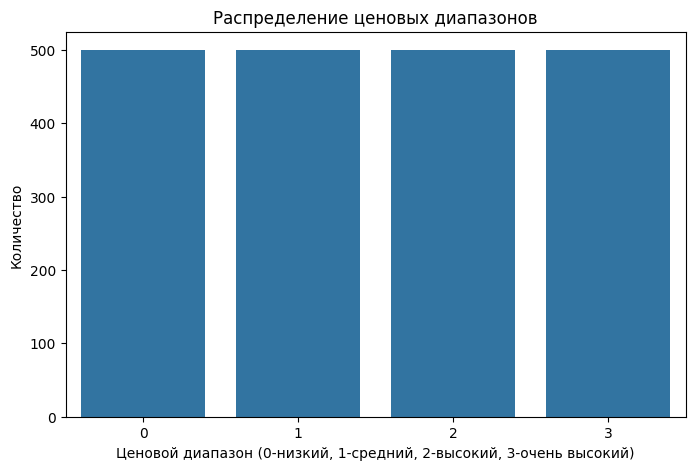

Распределение по классам:
price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='price_range')
plt.title('Распределение ценовых диапазонов')
plt.xlabel('Ценовой диапазон (0-низкий, 1-средний, 2-высокий, 3-очень высокий)')
plt.ylabel('Количество')
plt.show()

print("Распределение по классам:")
print(data['price_range'].value_counts())

Классы сбалансированы.

## Корреляция признаков

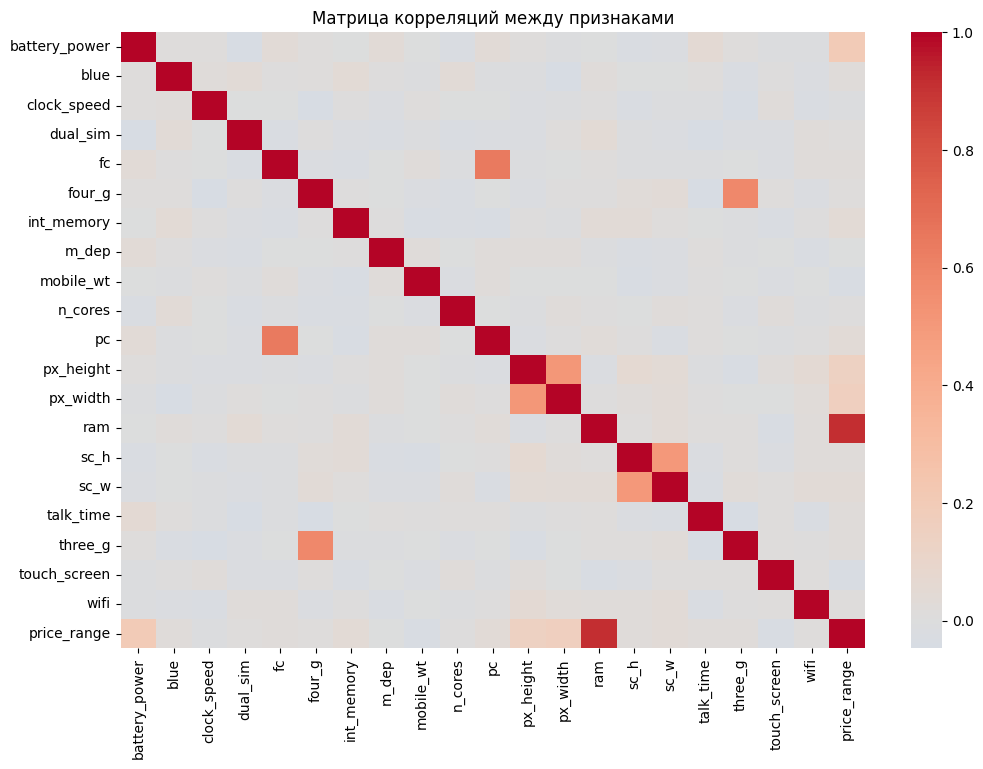


Корреляция признаков с целевой переменной:
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


In [6]:
# Матрица корреляций
plt.figure(figsize=(12, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Матрица корреляций между признаками')
plt.show()

# Корреляция признаков с ценой
correlation_with_target = data.corr()['price_range'].sort_values(ascending=False)
print("\nКорреляция признаков с целевой переменной:")
print(correlation_with_target)

Как видим, наибольшее влияние на ценовой сегмент оказывает количество оперативной памяти (RAM), а также с меньшем влиянием оказывает емкость батареи и размер экрана. Проанализируем наиболее важные признаки - RAM и ёмкость батареи.

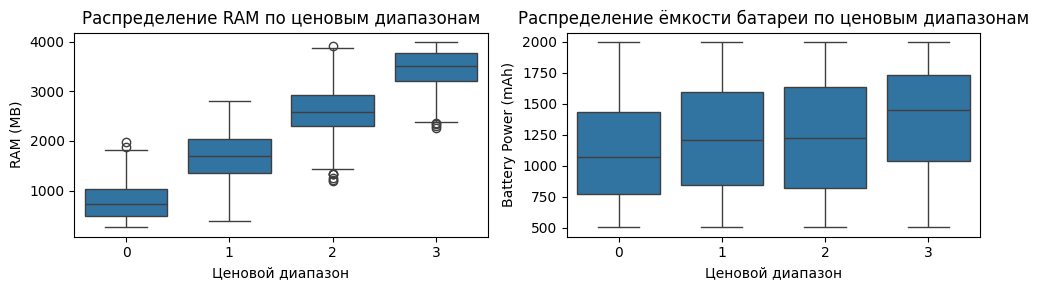

In [16]:
# 1. Анализ RAM
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=data, x='price_range', y='ram')
plt.title('Распределение RAM по ценовым диапазонам')
plt.xlabel('Ценовой диапазон')
plt.ylabel('RAM (MB)')

# 2. Анализ батареи
plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='price_range', y='battery_power')
plt.title('Распределение ёмкости батареи по ценовым диапазонам')
plt.xlabel('Ценовой диапазон')
plt.ylabel('Battery Power (mAh)')
plt.tight_layout()
plt.show()

Как видим, ценовая категория почти что линейно зависит от количества RAM, также как и от емкости батареи с чуть менее выраженной линейной зависимостью.

## Анализ бинарных признаков

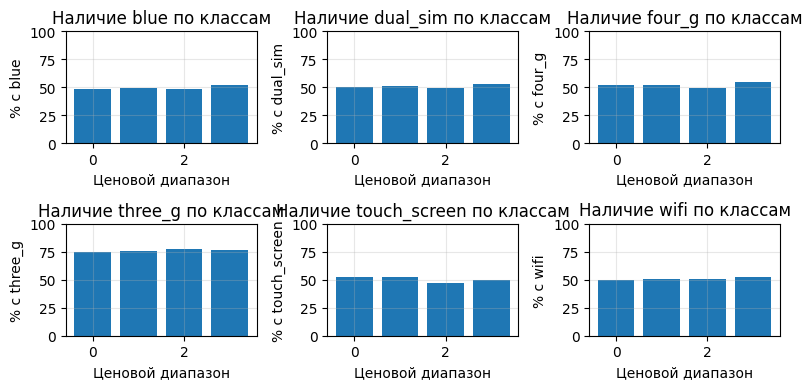

In [15]:
# Список бинарных признаков
binary_features = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

# Визуализация распределения бинарных признаков по классам
fig, axes = plt.subplots(2, 3, figsize=(8, 4))
axes = axes.ravel()

for idx, feature in enumerate(binary_features):
    # Процент наличия признака в каждом классе
    feature_by_price = data.groupby('price_range')[feature].mean() * 100

    axes[idx].bar(feature_by_price.index, feature_by_price.values)
    axes[idx].set_title(f'Наличие {feature} по классам')
    axes[idx].set_xlabel('Ценовой диапазон')
    axes[idx].set_ylabel(f'% с {feature}')
    axes[idx].set_ylim(0, 100)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Почти все бинарные признаки  слабо влияют на ценовую категорию.

## Промежуточные выводы
1. Данные без пропусков, все признаки числовые.
2. Классы сбалансированы — можно использовать accuracy как базовую метрику.
3. RAM — самый важный признак для определения цены.
4. Разрешение экрана и ёмкость батареи также влияют на цену.
5. Бинарные признаки слабо дифференцируют ценовые классы.
6. Сильной корреляции между признаками нет — можно использовать линейные модели.

# Решение задачи классификации

## Разделение на обучающую и тестовую выборки

In [18]:
from sklearn.model_selection import train_test_split

X = data.drop('price_range', axis=1) # Признаки
y = data['price_range'] # Целевая переменная

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Обучающая выборка: {X_train.shape}, {y_train.shape}")
print(f"Тестовая выборка: {X_test.shape}, {y_test.shape}")

Обучающая выборка: (1600, 20), (1600,)
Тестовая выборка: (400, 20), (400,)


## Масштабирование признаков


In [23]:
from sklearn.preprocessing import StandardScaler

# Создаем и обучаем scaler ТОЛЬКО на обучающих данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled = scaler.transform(X_test)        # только transform!

# Преобразуем обратно в DataFrame для удобства
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head(1)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
469,1.389193,1.011314,-1.259189,0.986343,1.309253,-1.036932,1.584829,-0.70459,-1.250335,-1.551637,0.350239,-0.798849,-1.285642,-0.363024,-0.78129,-0.177627,-0.896645,-1.788708,-1.008789,-1.02532


In [24]:
X_test_scaled.head(1)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
501,1.224774,1.011314,1.187471,-1.013846,2.692875,0.964384,-0.003457,0.333799,0.847614,0.635693,1.338859,1.278469,0.525696,1.327676,1.123206,0.050466,0.378745,0.559063,-1.008789,0.975305


## Выбор методов и обоснование

### Логистическая регрессия
Выбрана как базовая модель для сравнения с другими методами. Её задача — показать минимальный уровень качества модели. Если accuracy будет низким — это сигнал о сильных нелинейностях в данных. Можно увидеть, какой признак и насколько сильно влияет на вероятность отнесения к высокому ценовому классу.

### Случайный лес (Random Forest)
Выбрана как основная модель. Она автоматически находит сложные, нелинейные зависимости между признаками, которые линейная модель не видит (например, комбинация ram, px_height и battery_power).
Также метод выдаёт рейтинг важности признаков, который подтвердит или опровергнет гипотезы, возникшие на этапе предварительного анализа.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ - на масштабированных данных
print("=== Логистическая регрессия ===")
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled, y_train)
y_pred_logreg = logreg_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.3f}")
print("Отчет по классификации:\n", classification_report(y_test, y_pred_logreg))

# 2. СЛУЧАЙНЫЙ ЛЕС - на немасштабированных данных
print("\n=== Случайный лес ===")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("Отчет по классификации:\n", classification_report(y_test, y_pred_rf))

# ВАЖНОСТЬ ПРИЗНАКОВ (для Random Forest)
importances = rf_model.feature_importances_
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

print("\nТоп-5 важных признаков по версии Random Forest:")
print(feat_imp_df.head())

=== Логистическая регрессия ===
Accuracy: 0.965
Отчет по классификации:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400


=== Случайный лес ===
Accuracy: 0.880
Отчет по классификации:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.82      0.84      0.83       100
           2       0.81      0.79      0.80       100
           3       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88     

## Выводы
- Логистическая регрессия (0.965) показала результат лучше, чем случайный лес (0.88). Это говорит о том, что зависимость между признаками и ценой в наших данных в основном линейная. Главный признак ram линейно связан с ценой: Чем больше RAM, тем выше ценовой диапазон. Логистическая регрессия хорошо улавливает такие прямые зависимости.
- Случайный лес хуже всего справляется с классами 1 и 2 (средний и высокий) — их легко перепутать. Классы 0 и 3 (дешевые и очень дорогие) определяются с высокой точностью. Случайный лес искал нелинейные взаимодействия между признаками, которых в данных мало. В итоге модель переобучилась на шум, что снизило ее обобщающую способность.
